In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from mpl_toolkits.mplot3d import Axes3D
from math import ceil
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [109]:
#importing data
#data = pd.read_csv("cleaned_dataset.csv")
file_path = r"cleaned_dataset_without_criticalcolumns.csv"

df = pd.read_csv(file_path)

# check data
print(df.head()) 
df.info() 

         ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
0  10350017      2.0         4      85             23             10    12.4   
1  10350125      4.0         1      35             15              4     4.8   
2  10350125     11.0         0      11             10              0     2.2   
3  10350197      1.0         5     124             36             24    11.0   
4  10350199      4.0         4     123             21             59     9.4   

   CostCar  TimeCar  NbHousehold  ...  FreqTripHouseh  Region  distance_km  \
0     3.17       32          2.0  ...             4.0       1         30.0   
1     0.69        9          1.0  ...             3.0       1          7.0   
2     0.13        1          1.0  ...             3.0       1          1.0   
3     2.44       22          2.0  ...             3.0       1         26.0   
4     2.03       19          3.0  ...             2.0       1         22.0   

   Choice  InVehicleTime  ModeToSchool  ReportedDu

In [110]:
## target = ['Choice']

# Socio-demographic variables (Sub-question 1)
#socio_demo = ['age', 'Gender', 'Education', 'BirthYear', 'LangCode', 'FamilSitu', 'NbHousehold', 'NbChild']

# Vehicle Ownership & Availability (Sub-question 4)
#vehicle = ['NbCar', 'NbMoto', 'CarAvail']

# Spatial context (Sub-question 3)
#spatial_context = ['UrbRur', 'TypeCommune', 'ClassifCodeLine', 'Region', 'frequency']

# Trip utility (standard predictors for mode choice)
#trip_utility = ['TimePT', 'TimeCar', 'InVehicleTime', 'WalkingTimePT', 'WaitingTimePT', 
#                'distance_km', 'NbTransf', 'MarginalCostPT', 'CostCar']

# Historical & Childhood Background
#history = ['TripPurpose', 'DestAct', 'NbTrajects', 'FreqTripHouseh', 
 #                     'ModeToSchool', 'ResidChild', 'FreqTrainPar', 'FreqOtherPar']

# Attitudinal Statements (Sub-question 2: Environmental and Lifestyle)
attitudes = ['Envir01', 'Envir05', 'Mobil01', 'Mobil04', 'Mobil08', 'Mobil13', 
             'Mobil15', 'Mobil23', 'ResidCh05', 'ResidCh07', 'LifSty02', 
             'LifSty06', 'LifSty08', 'LifSty11']
ids = ['ID']

critical_cols = target + socio_demo + vehicle + spatial_context + trip_utility + history
critical_cols_id = ids + critical_cols
critical_data = data[critical_cols]
critical_data_id = data[critical_cols_id]
critical_data.head()

In [111]:
#attitude_data = data[attitudes]
#attitude_data.dropna()
#attitude_data.head()

In [6]:
# DATA PROCESSING
X = df.copy() # Kopieert data inclusief kolomnamen

# Feature scaling 

X = (X - X.mean()) / X.std()
print(X.head()) # Prints the first 5 rows of the DataFrame

         ID   DestAct  NbTransf    TimePT  WalkingTimePT  WaitingTimePT  \
0 -1.544740 -0.612278  0.898225 -0.287879      -0.650812      -0.171418   
1 -1.544735 -0.048664 -0.508659 -0.880189      -0.963512      -0.447474   
2 -1.544735  1.923983 -0.977620 -1.164498      -1.158950      -0.631511   
3 -1.544732 -0.894084  1.367186  0.174123      -0.142674       0.472711   
4 -1.544732 -0.048664  0.898225  0.162277      -0.728987       2.083035   

     CostPT   CostCar   TimeCar  NbHousehold  ...  FreqTripHouseh    Region  \
0 -0.276850 -0.159120 -0.189372    -0.702461  ...        1.126456 -1.726308   
1 -0.591527 -0.579801 -0.666325    -1.495303  ...        0.050982 -1.726308   
2 -0.699179 -0.674794 -0.832222    -1.495303  ...        0.050982 -1.726308   
3 -0.334816 -0.282950 -0.396743    -0.702461  ...        0.050982 -1.726308   
4 -0.401064 -0.352498 -0.458954     0.090380  ...       -1.024492 -1.726308   

   distance_km   Choice  InVehicleTime  ModeToSchool  ReportedDuration  \


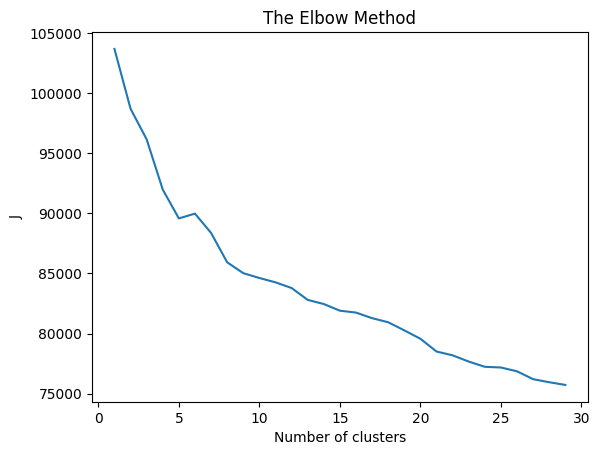

In [7]:
#decide on number of clusters using Elbow method
wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, init='k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [8]:
from sklearn.metrics import silhouette_score
kmeans_5 = KMeans(n_clusters=5, random_state=1, init='k-means++')
#test which amount of clusters is the better fit
labels_5 = kmeans_5.fit_predict(X)

score_5 = silhouette_score(X, labels_5)
print("Silhouette Score for 5 clusters is:", score_5)

kmeans_6 = KMeans(n_clusters=6, random_state=1, init='k-means++')
labels_6 = kmeans_6.fit_predict(X)

score_6 = silhouette_score(X, labels_6)
print("Silhouette Score for 6 clusters is:", score_6)

Silhouette Score for 5 clusters is: 0.07569320517626256
Silhouette Score for 6 clusters is: 0.06756401860985548


In [9]:
# test k from 2 to 10
range_n_clusters = range(2, 11)  
scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=1, init="k-means++").fit(X)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Best k
best_k = range_n_clusters[scores.index(max(scores))]
print("Best k:", best_k)

k=2, Silhouette Score=0.1032
k=3, Silhouette Score=0.0412
k=4, Silhouette Score=0.0415
k=5, Silhouette Score=0.0422
k=6, Silhouette Score=0.0416
k=7, Silhouette Score=0.0406
k=8, Silhouette Score=0.0307
k=9, Silhouette Score=0.0275
k=10, Silhouette Score=0.0311
Best k: 2


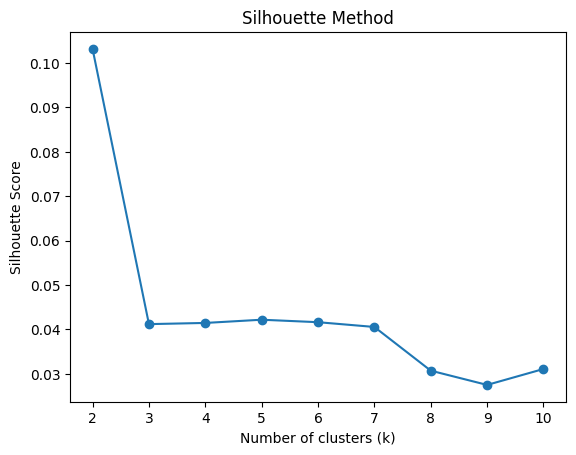

In [115]:
import matplotlib.pyplot as plt

plt.plot(range_n_clusters, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [21]:
#implement kmeans algorithm with 2 to 4 clusters based on the outcome of the elbow method and silhouette score
kmeans_2 = KMeans(n_clusters=2, random_state=1, init="k-means++").fit(X)
kmeans_3 = KMeans(n_clusters=3, random_state=1, init="k-means++").fit(X)
kmeans_4 = KMeans(n_clusters=4, random_state=1, init="k-means++").fit(X)
#add column for clusters
#add to original before feature scaling
data_cluster = org_X
data_cluster['Cluster_2']= kmeans_2.labels_
data_cluster['Cluster_3']= kmeans_3.labels_
data_cluster['Cluster_4']= kmeans_4.labels_
#add ID to compare results
data_cluster['ID'] = critical_data_id['ID']
data_cluster.head()


,Choice,age,Gender,Education,BirthYear,LangCode,FamilSitu,NbHousehold,NbChild,NbCar,...,NbTrajects,FreqTripHouseh,ModeToSchool,ResidChild,FreqTrainPar,FreqOtherPar,Cluster_2,Cluster_3,Cluster_4,ID
0,1.0,27.0,1.0,7.0,1983.0,1.0,2.0,2.0,0.0,1.0,...,2.0,4.0,3.0,5.0,1.0,1.0,0,2,2,10350017
1,1.0,64.0,2.0,4.0,1946.0,1.0,2.0,2.0,0.0,1.0,...,2.0,3.0,5.0,5.0,2.0,2.0,0,0,2,10350120
2,1.0,68.0,2.0,3.0,1942.0,1.0,1.0,1.0,0.0,1.0,...,1.0,3.0,4.0,3.0,2.0,2.0,0,0,0,10350125
3,1.0,68.0,2.0,3.0,1942.0,1.0,1.0,1.0,0.0,1.0,...,1.0,3.0,4.0,3.0,2.0,2.0,0,0,0,10350125
4,1.0,30.0,1.0,8.0,1980.0,1.0,2.0,2.0,0.0,2.0,...,2.0,3.0,1.0,5.0,3.0,1.0,0,2,2,10350197


    Envir01   Envir05   Mobil01   Mobil04   Mobil08   Mobil13   Mobil15  \
0  0.201357  1.332626  0.757689  0.701074 -1.120024  0.696126  1.077607   
1  0.887520  0.372702 -0.092074 -0.264947 -0.290307 -0.343955  0.065136   
2  0.887520  0.372702 -0.092074 -0.264947 -0.290307 -0.343955  0.065136   
3 -0.484806  0.372702 -0.941836  0.701074 -1.120024  0.696126  1.077607   
4  0.887520  1.332626 -1.791599 -0.264947 -1.120024  0.696126 -0.947334   

    Mobil23 ResidCh05 ResidCh07  LifSty02  LifSty06  LifSty08  LifSty11  
0  0.723599 -0.636603   0.84688  0.076336  1.614504  0.813357  0.162965  
1 -0.289211 -0.636603  -0.17677  0.966258 -0.659662 -0.204488 -0.768564  
2 -0.289211 -0.636603  -0.17677  0.966258 -0.659662 -0.204488 -0.768564  
3  1.736409 -0.636603   0.84688 -0.813585  0.098393 -3.258025  1.094494  
4 -0.289211 -0.636603   0.84688  0.076336 -0.659662  0.813357 -0.768564  


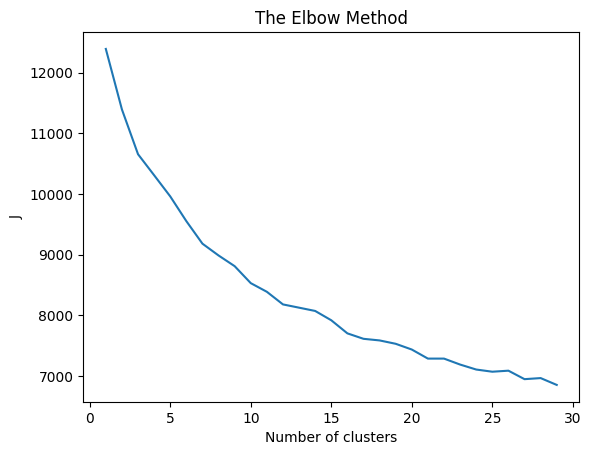

In [43]:
#check if attitudes gives better clusters
#DATA PROCESSING
X = attitude_data.iloc[:,:].values
X = pd.DataFrame(X)
#randomly select a subset of the dataset
#fix the randomness to be able to reproduce
#X = X.sample(n=6000, random_state=1) 
X.columns =  [attitudes] #attitudes to predict clusters
org_X_attitude = X.dropna() # to keep the version before feature scaling

# Feature scaling 
X = (X - X.mean()) / X.std()
X = X.dropna()
print(X.head()) # Prints the first 5 rows of the DataFrame
#decide on number of clusters using Elbow method


wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [44]:
#test which amount of clusters is the better fit

range_n_clusters = range(2, 11)  # test k from 2 to 10
scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=1, init="k-means++").fit(X)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Best k
best_k = range_n_clusters[scores.index(max(scores))]
print("Best k:", best_k)

k=2, Silhouette Score=0.0901
k=3, Silhouette Score=0.0753
k=4, Silhouette Score=0.0637
k=5, Silhouette Score=0.0625
k=6, Silhouette Score=0.0677
k=7, Silhouette Score=0.0718
k=8, Silhouette Score=0.0693
k=9, Silhouette Score=0.0718
k=10, Silhouette Score=0.0724
Best k: 2


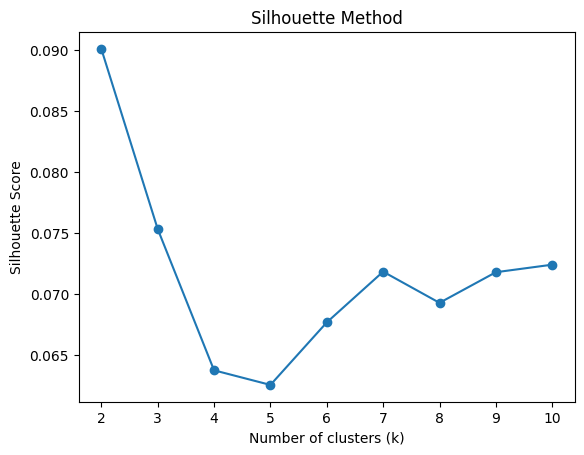

In [45]:
plt.plot(range_n_clusters, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [47]:
#implement kmeans algorithm with 4 clusters based on the outcome of the elbow method and silhouette score
kmeans_2 = KMeans(n_clusters=2, random_state=1, init="k-means++").fit(X)
kmeans_3 = KMeans(n_clusters=3, random_state=1, init="k-means++").fit(X)
kmeans_4 = KMeans(n_clusters=4, random_state=1, init="k-means++").fit(X)
#add column for clusters
#add to original before feature scaling
data_cluster_attitude = org_X_attitude
data_cluster_attitude['Cluster_2']= kmeans_2.labels_
data_cluster_attitude['Cluster_3']= kmeans_3.labels_
data_cluster_attitude['Cluster_4']= kmeans_4.labels_
data_cluster_attitude.head()

Envir01 Envir05 Mobil01 Mobil04 Mobil08 Mobil13 Mobil15 Mobil23 ResidCh05  \
0     3.0     5.0     5.0     5.0     1.0     5.0     5.0     5.0       1.0   
1     3.0     4.0     3.0     4.0     2.0     4.0     3.0     2.0       2.0   
2     4.0     4.0     4.0     4.0     2.0     4.0     4.0     4.0       1.0   
3     4.0     4.0     4.0     4.0     2.0     4.0     4.0     4.0       1.0   
4     2.0     4.0     3.0     5.0     1.0     5.0     5.0     6.0       1.0   

  ResidCh07 LifSty02 LifSty06 LifSty08 LifSty11 Cluster Cluster_2 Cluster_3  \
0       5.0      3.0      5.0      5.0      3.0       1         1         1   
1       4.0      3.0      4.0      4.0      3.0       2         0         0   
2       4.0      4.0      2.0      4.0      2.0       1         1         1   
3       4.0      4.0      2.0      4.0      2.0       1         1         1   
4       5.0      2.0      3.0      1.0      4.0       0         0         0   

  Cluster_4  
0         1  
1         2  
2         1  
3         1  
4         0

In [ ]:
data_cluster_attitude.columns = [col[0] for col in data_cluster_attitude.columns]

In [ ]:
##still to be updated

# plot clusters in 3d 
#labels = kmeans.predict(X)                      # Getting the cluster labels
centroids = kmeans.cluster_centers_             # Centroid values
print("Centroids are:", centroids)              # From sci-kit learn

#plot
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')

x = np.array(labels==0)
y = np.array(labels==1)
z = np.array(labels==2)


ax.scatter(X[x][:, 0], X[x][:, 1], X[x][:, 2], color='red')
ax.scatter(X[y][:, 0], X[y][:, 1], X[y][:, 2], color='blue')
ax.scatter(X[z][:, 0], X[z][:, 1], X[z][:, 2], color='yellow')
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
            marker='x', s=169, linewidths=10,
            color='black', zorder=50)

## SOURCE: https://stackoverflow.com/questions/64987810/3d-plotting-of-a-dataset-that-uses-k-means

